# More Examples

This tutorial walks through several real-world heatmap examples that
demonstrate the full power of ComplexHeatmap. Each example uses bundled
datasets and showcases different annotation and composition patterns:

1. Gene expression heatmap with annotations
2. The measles vaccine heatmap
3. Gene expression with k-means clustering
4. Custom color functions
5. Labeled sub-heatmaps
6. Methylation / expression data integration

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## 1. Gene expression heatmap

The bundled gene expression dataset contains rows (genes) and columns
(samples) with additional metadata columns. We extract only the numeric
expression values for the heatmap.

In [2]:
expr_df = load_gene_expression()
numeric_cols = expr_df.select_dtypes(include=[np.number]).columns
mat = expr_df[numeric_cols].values

print(f"Expression matrix shape: {mat.shape}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"Value range: [{np.nanmin(mat):.2f}, {np.nanmax(mat):.2f}]")

Expression matrix shape: (155, 25)
Numeric columns: 25
Value range: [4.56, 737389.00]


In [3]:
ht = Heatmap(mat, name="gene_expr")
ht.make_layout()
print(f"Heatmap dimensions: nrow={ht.nrow}, ncol={ht.ncol}")
print(f"Dims match input: {ht.nrow == mat.shape[0] and ht.ncol == mat.shape[1]}")

Heatmap dimensions: nrow=155, ncol=25
Dims match input: True


## Gene expression with custom color function

Using `color_ramp2` we map the expression range to a green-white-red
diverging color scale centered at zero.

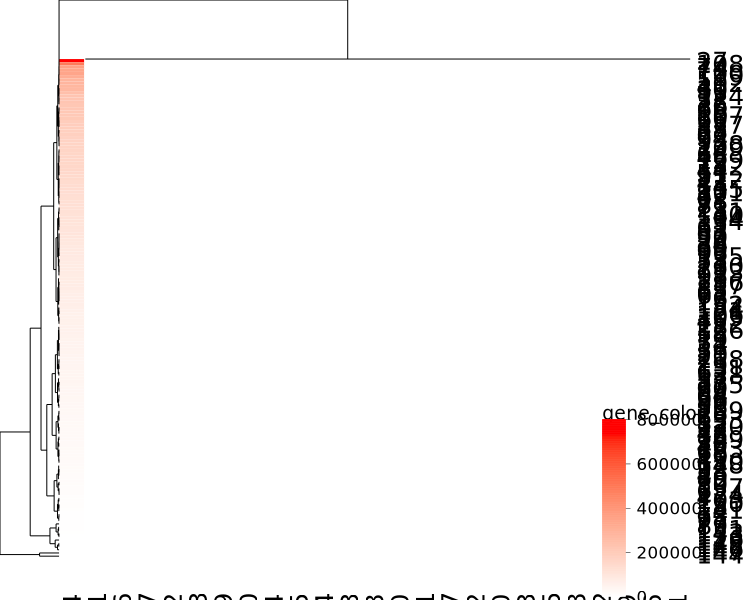

In [4]:
mat_min = min(np.nanmin(mat), -0.01)
mat_max = max(np.nanmax(mat), 0.01)

col_fun = color_ramp2(
    [mat_min, 0, mat_max], ["green", "white", "red"]
)

ht_col = Heatmap(mat, name="gene_color", col=col_fun)
ht_col.draw()

## Gene expression with top annotation

A barplot annotation showing per-column mean expression is added on top.

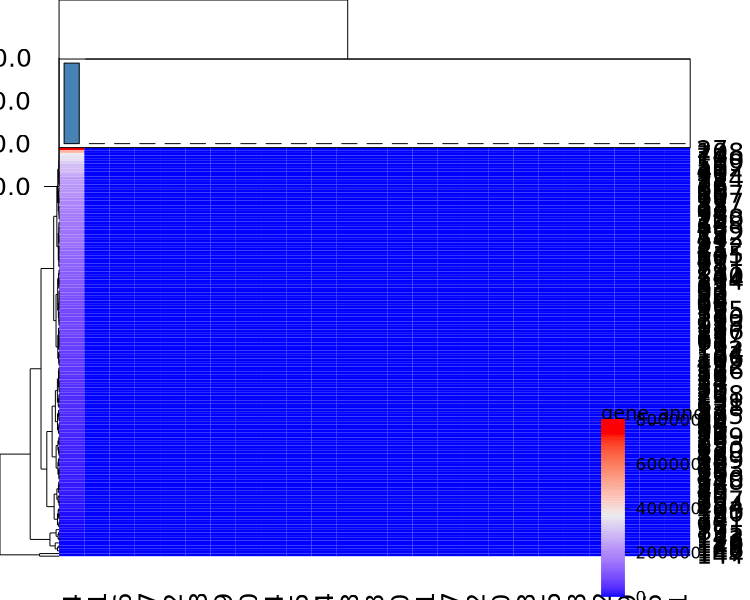

In [5]:
ha = HeatmapAnnotation(
    mean_val=anno_barplot(np.nanmean(mat, axis=0)),
)

ht_anno = Heatmap(
    mat,
    name="gene_anno",
    top_annotation=ha,
)
ht_anno.draw()

## Gene expression with k-means clustering

Setting `row_km=4` clusters genes into 4 groups by k-means on the
expression matrix.

In [6]:
np.random.seed(42)
ht_km = Heatmap(mat, name="gene_km", row_km=4)
ht_km.make_layout()

n_slices = len(ht_km.row_order_list())
print(f"row_km=4 produced {n_slices} slices")

row_km=4 produced 4 slices


## 2. The measles vaccine heatmap

This is a classic visualization: US measles incidence by state and year.
A vertical line marks the year the vaccine was introduced (1961).
Columns are kept in chronological order (no clustering).

In [7]:
measles_data = load_measles()
measles_mat = measles_data[0]
print(f"Measles matrix shape: {measles_mat.shape}")

Measles matrix shape: (59, 72)


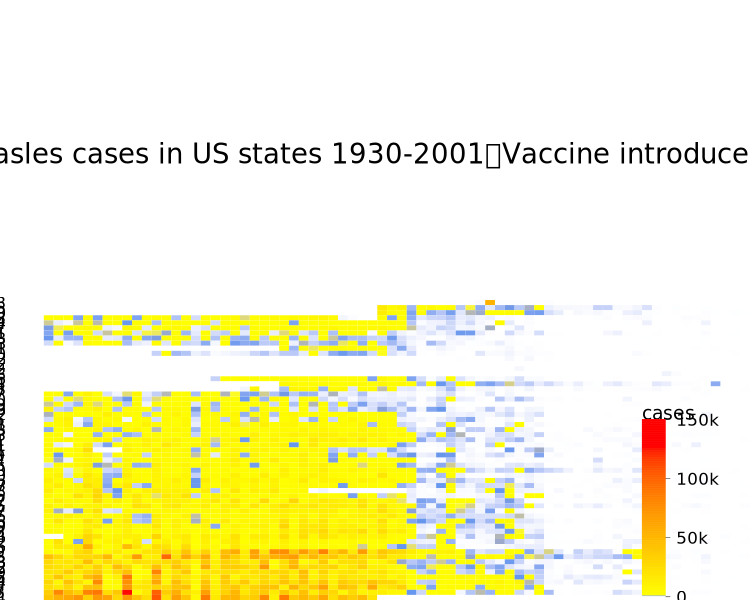

In [8]:
col_fun_measles = color_ramp2(
    [0, 800, 1000, 127000],
    ["white", "cornflowerblue", "yellow", "red"]
)

ht_m = Heatmap(
    measles_mat,
    name="cases",
    col=col_fun_measles,
    cluster_columns=False,
    show_row_dend=False,
    show_column_names=False,
    row_names_side="left",
    row_names_gp={"fontsize": 8},
    column_title="Measles cases in US states 1930-2001\nVaccine introduced 1961",
    heatmap_legend_param={
        "at": [0, 50000, 100000, 150000],
        "labels": ["0", "50k", "100k", "150k"],
    },
)
ht_m.draw()

## Verify measles heatmap dimensions

In [9]:
ht_m2 = Heatmap(measles_mat, name="measles_check", cluster_columns=False)
ht_m2.make_layout()
print(f"nrow={ht_m2.nrow}, ncol={ht_m2.ncol}")
print(f"Dims match: {ht_m2.nrow == measles_mat.shape[0] and ht_m2.ncol == measles_mat.shape[1]}")

nrow=59, ncol=72
Dims match: True


## 3. Labeled sub-heatmap

For small subsets of the data, row and column labels can be explicitly
provided to create a labeled heatmap.

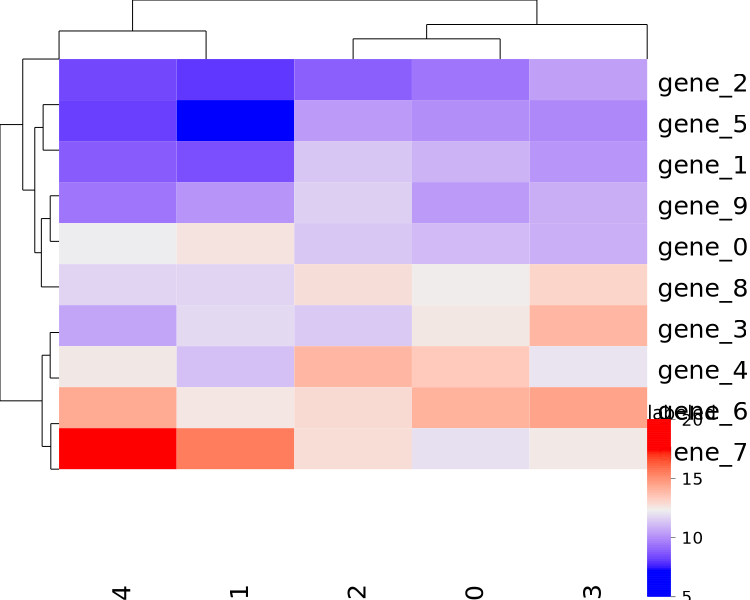

In [10]:
small_mat = mat[:10, :5]

ht_labels = Heatmap(
    small_mat,
    name="labeled",
    row_labels=[f"gene_{i}" for i in range(10)],
    column_labels=[f"sample_{j}" for j in range(5)],
)
ht_labels.draw()

## 4. Correlation matrix

A common pattern is to visualize sample-sample or gene-gene correlations
as a heatmap.

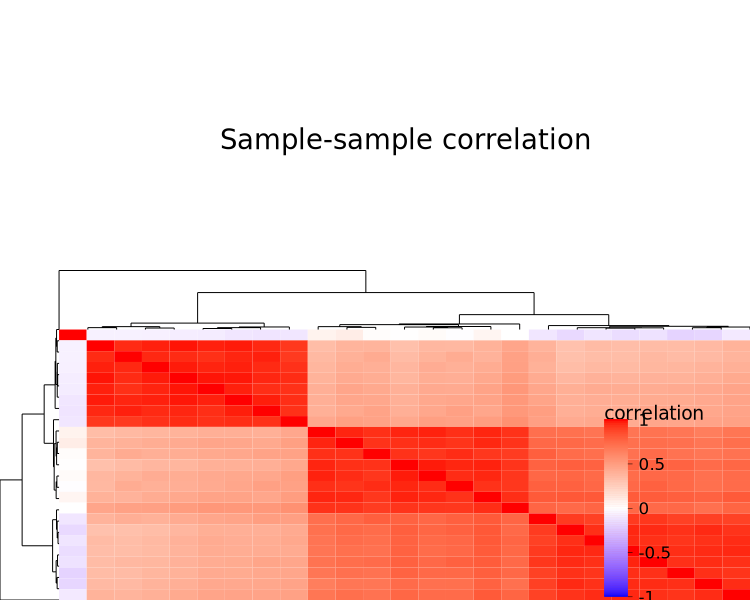

In [11]:
# Sample-sample correlation on gene expression
cor_mat = np.corrcoef(mat.T)  # columns = samples

cor_col = color_ramp2([-1, 0, 1], ["blue", "white", "red"])

ht_cor = Heatmap(
    cor_mat,
    name="correlation",
    col=cor_col,
    column_title="Sample-sample correlation",
    show_row_names=False,
    show_column_names=False,
)
ht_cor.draw()

## 5. Methylation and expression data integration

The bundled `load_random_meth_expr_data()` provides simulated methylation
and expression matrices that can be visualized side by side.

In [12]:
rd = load_random_meth_expr_data()
print(f"Keys: {list(rd.keys())}")

Keys: ['anno', 'mat_meth', 'mat_expr', 'tss_dist', 'anno_col', 'direction', 'cor_pvalue', 'gene_type']


In [13]:
mat_meth = rd["mat_meth"]

ht_meth = Heatmap(mat_meth, name="methylation")
ht_meth.make_layout()
print(f"Methylation matrix shape: {mat_meth.shape}")
print(f"Heatmap nrow={ht_meth.nrow}, ncol={ht_meth.ncol}")

Methylation matrix shape: (1000, 20)
Heatmap nrow=1000, ncol=20


## Methylation heatmap with color function

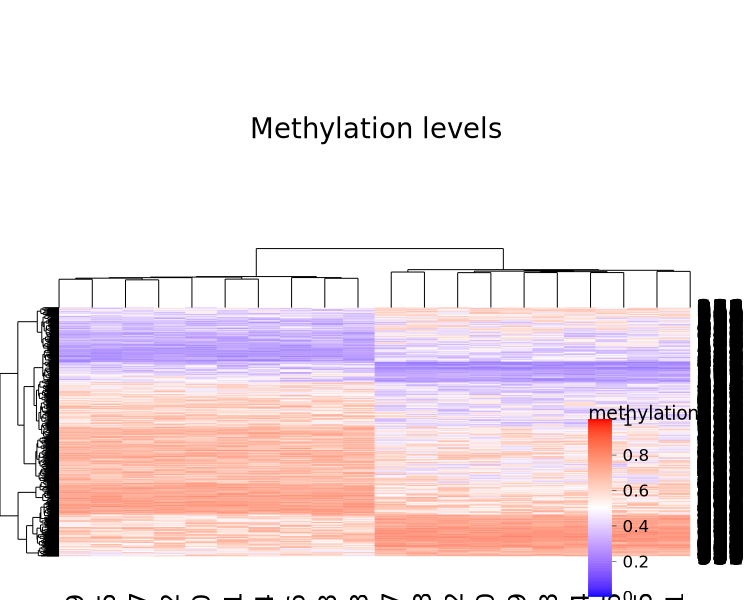

In [14]:
meth_col_fun = color_ramp2([0, 0.5, 1], ["blue", "white", "red"])

ht_meth_col = Heatmap(
    mat_meth,
    name="methylation",
    col=meth_col_fun,
    column_title="Methylation levels",
)
ht_meth_col.draw()

## Combined methylation and expression heatmap

If the dataset contains both `mat_meth` and `mat_expr`, we can concatenate
them horizontally to see the correspondence between methylation and
expression patterns.

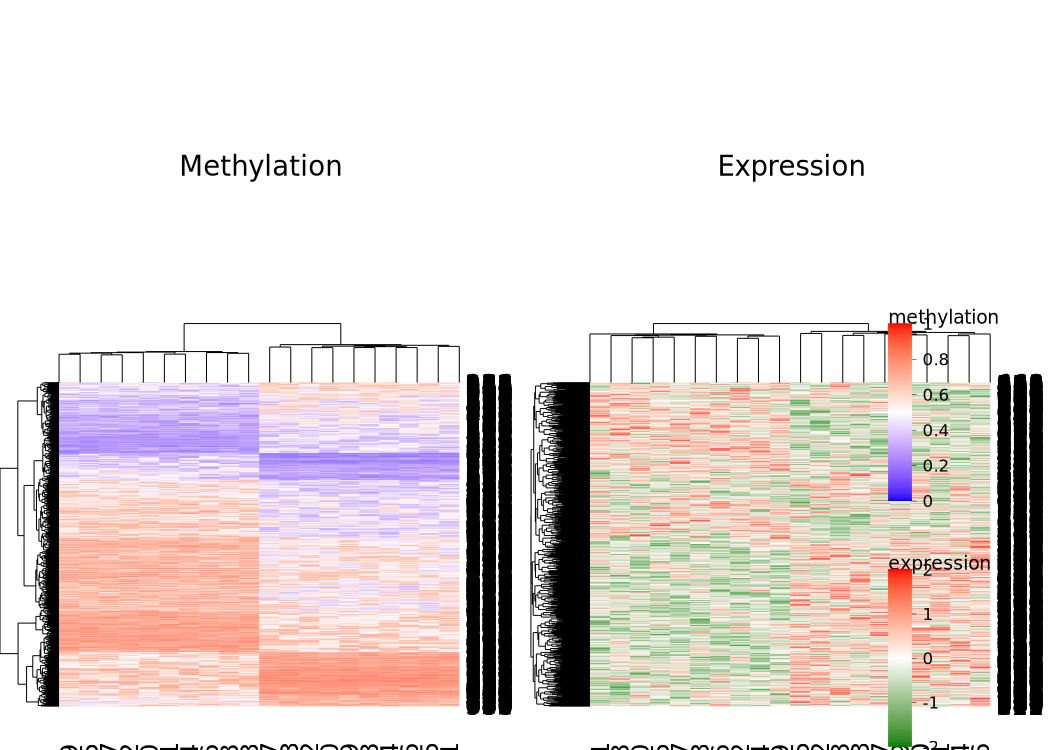

In [15]:
if "mat_expr" in rd:
    mat_expr = rd["mat_expr"]
    expr_col_fun = color_ramp2([-2, 0, 2], ["green", "white", "red"])

    ht_m = Heatmap(
        mat_meth,
        name="methylation",
        col=meth_col_fun,
        column_title="Methylation",
    )
    ht_e = Heatmap(
        mat_expr,
        name="expression",
        col=expr_col_fun,
        column_title="Expression",
    )

    ht_list = ht_m + ht_e
    ht_list.draw()
else:
    print("mat_expr not available; drawing methylation only.")
    ht_meth_col.draw()

## Integration with direction and annotation columns

If direction (hyper/hypo) information is available, it can be added as a
single-column heatmap next to the methylation data.

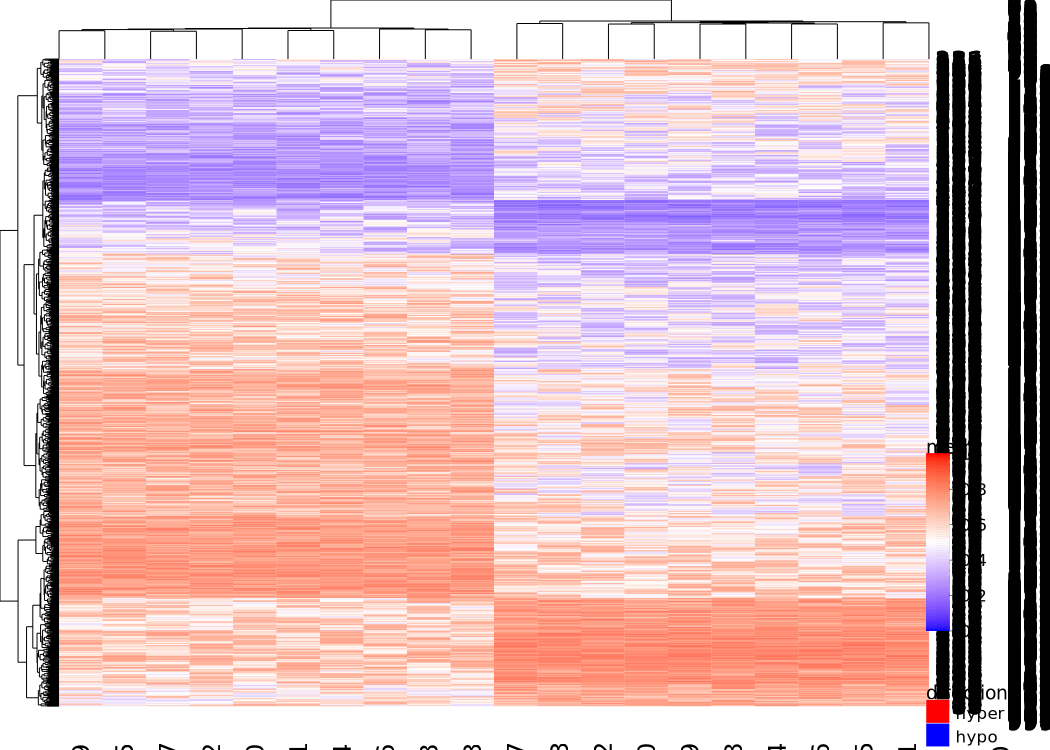

In [16]:
if "direction" in rd:
    direction = rd["direction"]
    direction_col = {"hyper": "red", "hypo": "blue"}

    ht_dir = Heatmap(
        direction,
        name="direction",
        col=direction_col,
    )

    ht_full = Heatmap(mat_meth, name="meth", col=meth_col_fun) + ht_dir
    ht_full.draw()
else:
    print("Direction data not available in this dataset.")

## Summary

This tutorial demonstrated several real-world heatmap examples:

- **Gene expression**: loading data, custom color functions, top annotations,
  k-means clustering
- **Measles incidence**: chronological column ordering, legend customization
- **Labeled heatmaps**: explicit row and column labels for small matrices
- **Correlation matrices**: sample-sample correlation visualization
- **Methylation data**: loading, coloring, and integrating with expression
  and direction data using `+` concatenation

Each example uses a bundled dataset from `complexheatmap` and demonstrates
patterns that are directly applicable to real analysis pipelines.